In [33]:
import pandas as pd
import importlib
import funciones as f #Tener funciones.py en mismo directorio. Tiene las funciones usadas para procesar un df
importlib.reload(f)

data = pd.read_csv('competition_data.csv')
submission = pd.read_csv('submission.csv')
submission_aux = pd.read_csv('submission.csv')

### Descomentar la siguiente celda la primera vez que se corre el notebook

In [34]:
# uri_to_ms_data = f.get_songs_durations(data)
# uri_to_ms_submission = f.get_songs_durations(submission)
# diccionario = {**uri_to_ms_data, **uri_to_ms_submission}

In [35]:
# Ejemplo de uso de procesar_df
submission = f.procesar_df(submission, diccionario)

In [36]:
submission

,Unnamed: 0,ts,platform,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,hour,day_of_week,month,year,is_iphone,duration_ms,is_early_finish,racha_early_finish,reason_appload,reason_backbtn,reason_clickrow,reason_fwdbtn,reason_playbtn,reason_remote,reason_trackdone,reason_trackerror,reason_unknown,track_prop,artist_prop,album_prop,hour day_of_week
0,74916,2014-06-27 18:01:15+00:00,"iOS 7.0.4 (iPod5,1)",Mejor,Los Tipitos,Push,spotify:track:5LFl6vXC2CwcciAbymL4jZ,False,18,4,6,14,1,232493.0,0,0,False,False,True,False,False,False,False,False,False,0.000040,0.001837,0.000519,72.0
1,74923,2014-09-04 21:46:57+00:00,"iOS 7.0.4 (iPod5,1)","Circles - Based On Ludovico Einaudi ""Experience""",Ludovico Einaudi,In a Time Lapse,spotify:track:0mEsOEi4rWBy0IXE5oTKr2,False,21,3,9,14,1,237500.0,0,0,False,False,False,True,False,False,False,False,False,0.000040,0.000240,0.000040,63.0
2,74924,2014-09-04 21:48:51+00:00,"iOS 7.0.4 (iPod5,1)",Primavera,Ludovico Einaudi,Divenire,spotify:track:0fzw4BBD5FRJtPuQbUUKzJ,False,21,3,9,14,1,445746.0,0,0,False,False,False,False,False,False,False,False,False,0.000040,0.000240,0.000200,63.0
3,74933,2016-06-23 21:07:59+00:00,OS X 10.11.5 [x86 4],NaN,NaN,NaN,NaN,False,21,3,6,16,0,NaN,0,0,False,False,True,False,False,False,False,False,False,NaN,NaN,NaN,63.0
4,74934,2016-06-23 21:08:03+00:00,OS X 10.11.5 [x86 4],NaN,NaN,NaN,NaN,False,21,3,6,16,0,NaN,0,0,False,False,True,False,False,False,False,False,False,NaN,NaN,NaN,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25032,74898,2024-05-22 15:28:48+00:00,ios,Zafar,La Vela Puerca,A Contraluz,spotify:track:1wIUWGdTdhVk5gIPd0ULxX,True,15,2,5,24,1,262000.0,0,0,False,False,False,False,False,False,True,False,False,0.000919,0.001598,0.001518,30.0
25033,74899,2024-05-22 15:35:04+00:00,ios,Un Loco En La Calesita,Juan Carlos Baglietto,Baglietto,spotify:track:3mHOEGxXbUpk5CZDgQhrUP,True,15,2,5,24,1,376426.0,1,1,False,False,False,True,False,False,False,False,False,0.000639,0.002117,0.001558,30.0
25034,74900,2024-05-22 15:39:44+00:00,ios,Dulce condena - Edición Aniversario,Los Rodriguez,Sin Documentos,spotify:track:4Pk1N5mY14kO5N3JcADgb2,True,15,2,5,24,1,280920.0,1,2,False,False,False,False,False,False,True,False,False,0.000719,0.006151,0.001238,30.0
25035,74901,2024-05-22 15:39:49+00:00,ios,Yo No Quiero Volverme Tan Loco,Charly García,Pubis Angelical / Yendo De La Cama Al Living,spotify:track:68LeIVjVDRMXPlfdFHhID6,True,15,2,5,24,1,310706.0,1,3,False,False,False,False,False,False,True,False,False,0.001358,0.021288,0.002836,30.0


In [37]:
# Ordenar data cronológicamente
data = f.sort_by_ts(data)

In [38]:
f.separate_ts(data)

In [39]:
# Holdout Set
from sklearn.metrics import roc_auc_score
import xgboost as xgb

#antes de seguir con operaciones por columna, separamos validation y train
# la idea es que train tenga 80% de datos de cada año, y val el resto
train_parts = []
val_parts = []

for year, group in data.groupby('year'):
    group = group.sort_values('ts')  # mantener orden cronológico dentro del año
    split_idx = int(len(group) * 0.8)
    train_parts.append(group.iloc[:split_idx])
    val_parts.append(group.iloc[split_idx:])

train_data = pd.concat(train_parts).sort_values('ts').reset_index(drop=True)
val_data = pd.concat(val_parts).sort_values('ts').reset_index(drop=True)

In [40]:
val_data = f.procesar_df(val_data, diccionario)
train_data = f.procesar_df(train_data, diccionario)

In [ ]:
drop_cols = [
    'Unnamed: 0','ts','TARGET',
    'master_metadata_track_name',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'spotify_track_uri','platform'
]
clf_xgb = xgb.XGBClassifier(objective = 'binary:logistic',
                            seed = 42,
                            eval_metric = 'auc',
                            early_stopping_rounds = 100)
clf_xgb.fit(train_data.drop(columns=drop_cols),
                train_data['TARGET'],
                eval_set=[(val_data.drop(columns=drop_cols), val_data['TARGET'])],
                verbose=True
                )

[0]	validation_0-auc:0.92271
[1]	validation_0-auc:0.92692
[2]	validation_0-auc:0.92833
[3]	validation_0-auc:0.92751
[4]	validation_0-auc:0.92845
[5]	validation_0-auc:0.92900
[6]	validation_0-auc:0.92935
[7]	validation_0-auc:0.92976
[8]	validation_0-auc:0.93042
[9]	validation_0-auc:0.93048
[10]	validation_0-auc:0.93012
[11]	validation_0-auc:0.93045
[12]	validation_0-auc:0.93071
[13]	validation_0-auc:0.93118
[14]	validation_0-auc:0.93133
[15]	validation_0-auc:0.93171
[16]	validation_0-auc:0.93167
[17]	validation_0-auc:0.93224
[18]	validation_0-auc:0.93225
[19]	validation_0-auc:0.93233
[20]	validation_0-auc:0.93243
[21]	validation_0-auc:0.93216
[22]	validation_0-auc:0.93223
[23]	validation_0-auc:0.93220
[24]	validation_0-auc:0.93224
[25]	validation_0-auc:0.93220
[26]	validation_0-auc:0.93227
[27]	validation_0-auc:0.93220
[28]	validation_0-auc:0.93204
[29]	validation_0-auc:0.93197
[30]	validation_0-auc:0.93187
[31]	validation_0-auc:0.93173
[32]	validation_0-auc:0.93176
[33]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

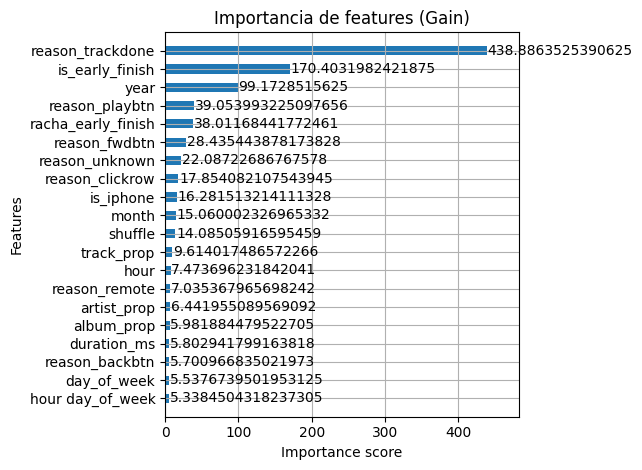

In [55]:
import matplotlib.pyplot as plt
xgb.plot_importance(clf_xgb, importance_type='gain', max_num_features=20, height=0.5)
plt.title("Importancia de features (Gain)")
plt.tight_layout()
plt.show()

In [42]:
best = clf_xgb.best_iteration
print(best)

prediccion_val = clf_xgb.predict_proba(val_data.drop(columns=drop_cols))[:, 1]
auc = roc_auc_score(val_data['TARGET'], prediccion_val)
print(f"AUC-ROC: {auc:.4f}")

20
AUC-ROC: 0.9324


In [48]:
#data = f.procesar_df(data, diccionario)
data

,Unnamed: 0,ts,platform,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,month,year,is_iphone,duration_ms,is_early_finish,racha_early_finish,reason_appload,reason_backbtn,reason_clickrow,reason_fwdbtn,reason_playbtn,reason_remote,reason_trackdone,reason_trackerror,reason_unknown,track_prop,artist_prop,album_prop,hour day_of_week
0,74917,2014-06-27 18:01:16+00:00,"iOS 7.0.4 (iPod5,1)",Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,6,14,1,344466.0,0,0,False,False,False,True,False,False,False,False,False,0.000010,0.002067,0.000679,72.0
1,74918,2014-06-29 20:10:10+00:00,"iOS 7.0.4 (iPod5,1)",Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,6,14,1,385880.0,0,0,False,False,False,False,False,False,False,False,False,0.000020,0.000429,0.000020,120.0
2,74919,2014-06-29 20:10:54+00:00,"iOS 7.0.4 (iPod5,1)",Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,6,14,1,348624.0,1,1,False,False,False,True,False,False,False,False,False,0.000389,0.000869,0.000310,120.0
3,74920,2014-06-29 20:11:16+00:00,"iOS 7.0.4 (iPod5,1)",Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,6,14,1,140773.0,1,2,False,False,False,True,False,False,False,False,False,0.000399,0.001238,0.000669,120.0
4,74921,2014-09-04 21:46:24+00:00,"iOS 7.0.4 (iPod5,1)","Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,9,14,1,140733.0,0,0,False,False,False,False,False,False,False,False,False,0.000020,0.000020,0.000020,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,74911,2024-05-23 17:24:56+00:00,ios,The Tide Is High,Blondie,Atomic/Atomix,spotify:track:52Rp3xBJFYYdmpgzDy0Quf,True,False,17,3,5,24,1,232733.0,0,0,False,False,False,False,False,False,True,False,False,0.000409,0.000759,0.000419,51.0
100140,74912,2024-05-23 17:28:33+00:00,ios,The Less I Know The Better,Tame Impala,Currents,spotify:track:6K4t31amVTZDgR3sKmwUJJ,True,False,17,3,5,24,1,216320.0,0,0,False,False,False,False,False,False,True,False,False,0.001907,0.002277,0.002087,51.0
100141,74913,2024-05-23 23:44:01+00:00,ios,Pink + White,Frank Ocean,Blonde,spotify:track:3xKsf9qdS1CyvXSMEid6g8,True,False,23,3,5,24,1,184516.0,0,0,False,False,False,False,False,False,True,False,False,0.000040,0.000260,0.000050,69.0
100142,74914,2024-05-23 23:50:25+00:00,ios,Still Got The Blues,Gary Moore,Still Got The Blues,spotify:track:0DnGfA1r8pAssJCuq4ojla,True,False,23,3,5,24,1,370866.0,0,0,False,False,True,False,False,False,False,False,False,0.000070,0.000300,0.000110,69.0


In [52]:
drop_cols = [
    'Unnamed: 0','ts', 'TARGET',
    'master_metadata_track_name',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'spotify_track_uri','platform'
]

clf_xgb_subm = xgb.XGBClassifier(objective = 'binary:logistic',
                            seed = 42,
                            eval_metric = 'auc',
                            n_estimators=25)
clf_xgb_subm.fit(data.drop(columns=drop_cols), data['TARGET'])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=25,
              n_jobs=None, num_parallel_tree=None, ...)

In [53]:
drop_cols = [
    'Unnamed: 0','ts',
    'master_metadata_track_name',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'spotify_track_uri','platform'
]

prediccion_submmit = clf_xgb_subm.predict_proba(submission.drop(columns=drop_cols))[:, 1]

In [ ]:
results = pd.DataFrame({'ID': submission['Unnamed: 0'], 'TARGET': prediccion_submmit})
results = results.set_index('ID').loc[submission_aux['Unnamed: 0']].reset_index()
# results.to_csv('submission18.csv', index=False)